In [4]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 0) Prepare data
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

n_samples, n_features = X.shape

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# scale
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

y_train = y_train.view(y_train.shape[0], 1)
y_test = y_test.view(y_test.shape[0], 1)

# 1) Model
# Linear model f = wx + b , sigmoid at the end
class Model(nn.Module):
    def __init__(self, n_input_features):
        super(Model, self).__init__()
        self.linear = nn.Linear(n_input_features, 1)

    def forward(self, x):
        y_pred = torch.sigmoid(self.linear(x))
        return y_pred

model = Model(n_features)

# 2) Loss and optimizer
num_epochs = 100
learning_rate = 0.01
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# 3) Training loop
losses = []
for epoch in range(num_epochs):
    # Forward pass and loss
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())

    # Backward pass and update
    loss.backward()
    optimizer.step()

    # zero grad before new step
    optimizer.zero_grad()

    if (epoch+1) % 10 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

with torch.no_grad():
    y_predicted = model(X_test)
    y_predicted_cls = y_predicted.round()
    acc = y_predicted_cls.eq(y_test).sum() / float(y_test.shape[0])
    print(f'accuracy: {acc.item():.4f}')


epoch: 10, loss = 0.4909
epoch: 20, loss = 0.4127
epoch: 30, loss = 0.3615
epoch: 40, loss = 0.3252
epoch: 50, loss = 0.2981
epoch: 60, loss = 0.2769
epoch: 70, loss = 0.2598
epoch: 80, loss = 0.2457
epoch: 90, loss = 0.2338
epoch: 100, loss = 0.2236
accuracy: 0.9035


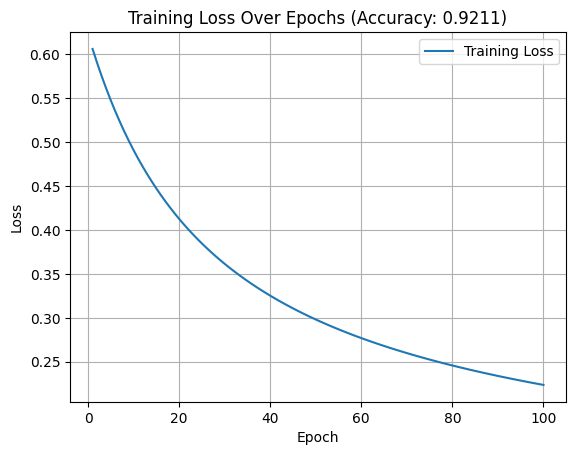

In [8]:
# Plotting the loss
plt.figure()
plt.plot(range(1, num_epochs + 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training Loss Over Epochs (Accuracy: {acc.item():.4f})')
plt.legend()
plt.grid(True)
plt.show()

## ✅ nn.Sequential을 활용한 모델 정의 (간소화 버전)

### 🔹 개념
기존에는 `nn.Module`을 상속받아 클래스를 정의했지만,  
간단한 구조의 모델은 `nn.Sequential`을 사용하면 훨씬 직관적으로 구성할 수 있습니다.

---

### 🔸 비교 정리

| 단계 | 기존 방식 (Class) | 변경된 방식 (Sequential) |
|------|------------------|--------------------------|
| 모델 정의 | `class Model(nn.Module): ...` | `model = nn.Sequential(nn.Linear(n_features, 1), nn.Sigmoid())` |
| 순전파 | `y_pred = model(X_train)` | `y_pred = model(X_train)` (동일) |

---

In [9]:
# 모델 (한 줄)
model = nn.Sequential(nn.Linear(X_train.shape[1], 1), nn.Sigmoid())

# 학습
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.BCELoss()

for epoch in range(1, 101):
    loss = criterion(model(X_train), y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f'epoch {epoch:3d} | loss: {loss.item():.4f}')

# 평가
with torch.no_grad():
    acc = model(X_test).round().eq(y_test).float().mean()
    print(f'accuracy: {acc:.4f}')

epoch  10 | loss: 0.8557
epoch  20 | loss: 0.6444
epoch  30 | loss: 0.5251
epoch  40 | loss: 0.4506
epoch  50 | loss: 0.3997
epoch  60 | loss: 0.3624
epoch  70 | loss: 0.3338
epoch  80 | loss: 0.3109
epoch  90 | loss: 0.2922
epoch 100 | loss: 0.2765
accuracy: 0.9035
